In [ ]:
# %%
# ============================================================
# ☀️ CELL 1 — SETUP + 23 FLARES (AIA ONLY)
# ============================================================

import os, glob, cv2
import numpy as np
from datetime import datetime, timedelta
from dotenv import load_dotenv
from astropy.io import fits
import astropy.units as u
from sunpy.net import Fido, attrs as a
from tqdm import tqdm  # <-- NEW: progress bar

# Load JSOC Email
load_dotenv()
EMAIL = os.environ.get("EMAIL")
if not EMAIL:
    raise ValueError("❌ Missing EMAIL in .env – Add EMAIL=your_jsoc_email")

# Base directory
BASE_DIR = os.path.abspath(".")
print(f"📂 Base directory: {BASE_DIR}")
print(f"📧 Using JSOC email: {EMAIL}")


#FLARES = [
  #  ("AR11158_M6.6","2011-02-13 17:28:00"),
   # ("AR11158_X2.2","2011-02-15 01:44:00"),
  #  ("AR11261_M9.3","2011-07-30 02:04:00"),
  #  ("AR11429_X5.4","2012-03-07 00:02:00"),
   #  ("AR11429_M6.3","2012-03-09 03:22:00"),
   #  ("AR11520_X1.4","2012-07-12 15:37:00"),
  #  ("AR11719_M6.5","2013-04-11 06:55:00"),
   #  ("AR12036_M7.3","2014-04-18 12:31:00"),
   #  ("AR11944_X1.2","2014-01-07 18:04:00"),
   #  ("AR12017_X1.0","2014-03-29 17:35:00"),
# ]

# === FINAL 23 FLARES ===
FLARES = [
    ("AR11166_X1.5", "2011-03-09 23:13:00"),
    ("AR11261_M6.0", "2011-08-03 13:17:00"),
    ("AR11261_M9.3b", "2011-08-04 03:41:00"),
    ("AR11283_M5.3", "2011-09-06 01:35:00"),
    ("AR11283_X2.1", "2011-09-06 22:12:00"),
    ("AR11283_X1.8", "2011-09-07 22:32:00"),
    ("AR11283_M6.7", "2011-09-08 15:32:00"),
    ("AR11302_M7.4", "2011-09-25 04:31:00"),
    ("AR11402_M8.7", "2012-01-23 03:38:00"),
    ("AR11429_X1.3", "2012-03-07 01:05:00"),
    ("AR11429_M8.4", "2012-03-10 17:15:00"),
    ("AR11476_M5.7", "2012-05-10 04:11:00"),
    ("AR11515_M5.6", "2012-07-02 10:43:00"),
    ("AR11515_M5.3", "2012-07-04 09:47:00"),
    ("AR11515_M6.1", "2012-07-05 11:39:00"),
    ("AR11877_M9.3", "2013-10-24 00:21:00"),
    ("AR11884_M6.3", "2013-11-01 19:46:00"),
    ("AR11884_M5.0", "2013-11-03 05:16:00"),
    ("AR11890_X1.1a","2013-11-08 04:20:00"),
    ("AR11890_X1.1b","2013-11-10 05:08:00"),
    ("AR11936_M6.4", "2013-12-31 21:45:00"),
    ("AR11944_M7.2", "2014-01-07 10:07:00"),
    ("AR12035_X1.3", "2014-04-25 00:17:00"),
]

print(f"🌞 Total flares: {len(FLARES)}")


📂 Base directory: /Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data
📧 Using JSOC email: ss5369@njit.edu
🌞 Total flares: 23


/opt/miniconda3/envs/surya_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# %%
# ============================================================
# ☀️ CELL 2 — AIA DOWNLOAD (+30 MIN FORWARD) WITH PROGRESS BAR
# ============================================================

AIA_SERIES = [
    ("aia.lev1_euv_12s", "image", [94,131,171,193,211,304,335]),
    ("aia.lev1_uv_24s",  "image", [1600]),
]

def download_aia_from_jsoc(start_time, end_time, save_dir, email):
    os.makedirs(save_dir, exist_ok=True)
    any_found = False

    for series, seg, wavelengths in tqdm(AIA_SERIES, desc="AIA Series"):
        for wl in wavelengths:
            try:
                print(f"🔹 AIA {wl}Å: {start_time} → {end_time}")
                query = Fido.search(
                    a.Time(start_time, end_time),
                    a.jsoc.Series(series),
                    a.Sample(12 * u.minute),
                    a.jsoc.PrimeKey("WAVELNTH", wl),
                    a.jsoc.Segment(seg),
                    a.jsoc.Notify(email),
                )
                if len(query) > 0:
                    Fido.fetch(query, path=save_dir, overwrite=False)
                    any_found = True
            except Exception as e:
                print(f"⚠️ AIA {wl}Å FAILED: {e}")
    return any_found


In [3]:
# %%
# ============================================================
# ☀️ CELL 3 — FITS → NPZ + DELETE FITS
# ============================================================

def fits_to_npz_and_cleanup(save_dir, out_npz, target_size=(256, 256)):
    fits_files = glob.glob(os.path.join(save_dir, "*.fits"))
    if not fits_files:
        print(f"⚠️ No FITS in {save_dir}")
        return False

    stacks = {}
    for fpath in tqdm(fits_files, desc="Converting FITS"):
        try:
            data = fits.getdata(fpath).astype(np.float32)
            lo, hi = np.percentile(data, 1), np.percentile(data, 99)
            data = np.clip(data, lo, hi)
            data = np.log1p(data - lo + 1e-6)
            data = cv2.resize(data, target_size)

            ch = "unknown"
            for wl in ["94","131","171","193","211","304","335","1600"]:
                if f".{wl}" in fpath or f"_{wl}." in fpath:
                    ch = f"aia{wl}"
                    break

            stacks.setdefault(ch, []).append(data)

        except Exception as e:
            print(f"⚠️ FITS READ ERROR: {e}")

    np.savez_compressed(out_npz, **{k: np.stack(v) for k, v in stacks.items()})
    print(f"💾 SAVED: {out_npz}  ({len(stacks)} channels)")

    for fpath in fits_files:
        try: os.remove(fpath)
        except: pass

    print(f"🧹 Deleted {len(fits_files)} FITS files")
    return True


In [4]:
# %%
# ============================================================
# ☀️ CELL 4 — MAIN LOOP (AIA ONLY, SEPARATE FOLDERS + PROGRESS BAR)
# ============================================================

OFFSETS = [-24, -18, -12, -6, 0, 6]

for flare_name, flare_start in tqdm(FLARES, desc="Processing Flares"):
    flare_folder = os.path.join(BASE_DIR, flare_name, "full_disk", "AIA")
    os.makedirs(flare_folder, exist_ok=True)

    flare_start_dt = datetime.strptime(flare_start, "%Y-%m-%d %H:%M:%S")

    print(f"\n🔥 {flare_name} ({flare_start})")

    for h in OFFSETS:
        t0 = flare_start_dt + timedelta(hours=h)
        t1 = t0 + timedelta(minutes=30)

        tag = t0.strftime("%Y%m%dT%H%M")
        save_dir = os.path.join(flare_folder, tag)
        out_npz = os.path.join(flare_folder, f"{tag}.npz")
        os.makedirs(save_dir, exist_ok=True)

        if os.path.exists(out_npz):
            print(f"⏭️ Already exists → {out_npz}")
            continue

        print(f"\n🕓 AIA window:  {t0} → {t1}")
        found = download_aia_from_jsoc(
            t0.strftime("%Y-%m-%dT%H:%M:%S"),
            t1.strftime("%Y-%m-%dT%H:%M:%S"),
            save_dir,
            EMAIL
        )

        if found:
            fits_to_npz_and_cleanup(save_dir, out_npz)
        else:
            print("🚫 No data found.")

print("\n🎯 Finished — ALL AIA data ready in /full_disk/AIA/.")


Processing Flares:   0%|          | 0/23 [00:00<?, ?it/s]


🔥 AR11166_X1.5 (2011-03-09 23:13:00)

🕓 AIA window:  2011-03-08 23:13:00 → 2011-03-08 23:43:00


🔹 AIA 94Å: 2011-03-08T23:13:00 → 2011-03-08T23:43:00


2025-11-24 22:49:45 - drms - INFO: Export request pending. [id=JSOC_20251125_001232, status=2]
2025-11-24 22:49:45 - drms - INFO: Waiting for 0 seconds...
2025-11-24 22:49:46 - drms - INFO: Export request pending. [id=JSOC_20251125_001232, status=1]
2025-11-24 22:49:46 - drms - INFO: Waiting for 5 seconds...
2025-11-24 22:49:51 - drms - INFO: Export request pending. [id=JSOC_20251125_001232, status=1]
2025-11-24 22:49:51 - drms - INFO: Waiting for 5 seconds...
2025-11-24 22:49:57 - drms - INFO: Export request pending. [id=JSOC_20251125_001232, status=1]
2025-11-24 22:49:57 - drms - INFO: Waiting for 5 seconds...
2025-11-24 22:50:03 - drms - INFO: Export request pending. [id=JSOC_20251125_001232, status=1]
2025-11-24 22:50:03 - drms - INFO: Waiting for 5 seconds...
2025-11-24 22:50:09 - drms - INFO: Export request pending. [id=JSOC_20251125_001232, status=1]
2025-11-24 22:50:09 - drms - INFO: Waiting for 5 seconds...
2025-11-24 22:50:14 - drms - INFO: Export request pending. [id=JSOC_20

INFO: 3 URLs found for download. Full request totaling 22MB [sunpy.net.jsoc.jsoc]


...

🔹 AIA 1600Å: 2014-04-25T06:17:00 → 2014-04-25T06:47:00


2025-11-25 13:32:39 - drms - INFO: Export request pending. [id=JSOC_20251125_007363, status=2]
2025-11-25 13:32:39 - drms - INFO: Waiting for 0 seconds...
2025-11-25 13:32:40 - drms - INFO: Export request pending. [id=JSOC_20251125_007363, status=1]
2025-11-25 13:32:40 - drms - INFO: Waiting for 5 seconds...
2025-11-25 13:32:46 - drms - INFO: Export request pending. [id=JSOC_20251125_007363, status=1]
2025-11-25 13:32:46 - drms - INFO: Waiting for 5 seconds...
2025-11-25 13:32:51 - drms - INFO: Export request pending. [id=JSOC_20251125_007363, status=1]
2025-11-25 13:32:51 - drms - INFO: Waiting for 5 seconds...
2025-11-25 13:32:57 - drms - INFO: Export request pending. [id=JSOC_20251125_007363, status=1]
2025-11-25 13:32:57 - drms - INFO: Waiting for 5 seconds...
2025-11-25 13:33:03 - drms - INFO: Export request pending. [id=JSOC_20251125_007363, status=1]
2025-11-25 13:33:03 - drms - INFO: Waiting for 5 seconds...
2025-11-25 13:33:08 - drms - INFO: Export request pending. [id=JSOC_20

INFO: 3 URLs found for download. Full request totaling 30MB [sunpy.net.jsoc.jsoc]


Processing Flares: 100%|██████████| 23/23 [14:43:55<00:00, 2305.90s/it]

💾 SAVED: /Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data/AR12035_X1.3/full_disk/AIA/20140425T0617.npz  (8 channels)
🧹 Deleted 24 FITS files

🎯 Finished — ALL AIA data ready in /full_disk/AIA/.


In [6]:
# %%
# ============================================================
# 📊 CHECK ALL AIA NPZ FILES - CHANNEL INVENTORY
# ============================================================
# Running from flare_data directory
# ============================================================

import os
import numpy as np
from collections import defaultdict

print("="*70)
print("AIA NPZ FILE INVENTORY")
print("="*70)

# ✅ FIXED: No BASE_DIR needed, we're already in flare_data
CURRENT_DIR = "."  # Current directory is flare_data

# Expected AIA channels
EXPECTED_CHANNELS = ["aia94", "aia131", "aia171", "aia193", 
                     "aia211", "aia304", "aia335", "aia1600"]

flare_summary = []
missing_channels = defaultdict(list)
incomplete_flares = []

# Scan all flares in current directory
for flare_name in os.listdir(CURRENT_DIR):
    flare_full_path = os.path.join(CURRENT_DIR, flare_name)
    
    # Skip if not a directory
    if not os.path.isdir(flare_full_path):
        continue
    
    # Look for npz_aia folder
    flare_path = os.path.join(flare_name, "full_disk", "npz_aia")
    
    if not os.path.isdir(flare_path):
        continue
    
    print(f"\n🔥 Checking: {flare_name}")
    
    # Find all NPZ files
    npz_files = [f for f in os.listdir(flare_path) if f.endswith('.npz')]
    
    if not npz_files:
        print(f"   ⚠️  No NPZ files found!")
        incomplete_flares.append((flare_name, "No NPZ files"))
        continue
    
    print(f"   Found {len(npz_files)} NPZ files")
    
    # Check each NPZ
    for npz_file in sorted(npz_files):
        npz_path = os.path.join(flare_path, npz_file)
        
        try:
            data = np.load(npz_path)
            channels = list(data.keys())
            
            # Check completeness
            missing = set(EXPECTED_CHANNELS) - set(channels)
            
            if missing:
                print(f"   ⚠️  {npz_file}: Missing {len(missing)} channels: {missing}")
                for ch in missing:
                    missing_channels[ch].append(f"{flare_name}/{npz_file}")
            else:
                print(f"   ✅ {npz_file}: All 8 channels present")
            
            # Store summary
            flare_summary.append({
                'flare': flare_name,
                'file': npz_file,
                'channels': len(channels),
                'channel_list': channels,
                'complete': len(missing) == 0
            })
            
        except Exception as e:
            print(f"   ❌ {npz_file}: Error loading - {e}")
            incomplete_flares.append((flare_name, f"{npz_file} - {e}"))

# Print summary
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

total_npz = len(flare_summary)
complete_npz = sum(1 for s in flare_summary if s['complete'])
incomplete_npz = total_npz - complete_npz

print(f"\nTotal NPZ files scanned: {total_npz}")
print(f"  ✅ Complete (8 channels): {complete_npz}")
print(f"  ⚠️  Incomplete: {incomplete_npz}")

if missing_channels:
    print(f"\n⚠️  Channels with missing data:")
    for ch, files in sorted(missing_channels.items()):
        print(f"   {ch}: Missing in {len(files)} files")

if incomplete_flares:
    print(f"\n⚠️  Flares with issues:")
    for flare, issue in incomplete_flares:
        print(f"   {flare}: {issue}")

# Channel distribution
channel_counts = defaultdict(int)
for s in flare_summary:
    for ch in s['channel_list']:
        channel_counts[ch] += 1

if total_npz > 0:
    print(f"\n📊 Channel availability across all NPZ files:")
    for ch in sorted(channel_counts.keys()):
        print(f"   {ch:10s}: {channel_counts[ch]:3d}/{total_npz} files ({channel_counts[ch]/total_npz*100:.1f}%)")

print("\n" + "="*70)
print("✅ Inventory complete!")

AIA NPZ FILE INVENTORY

🔥 Checking: AR11515_M5.6
   Found 6 NPZ files
   ✅ 20120701T1043.npz: All 8 channels present
   ✅ 20120701T1643.npz: All 8 channels present
   ✅ 20120701T2243.npz: All 8 channels present
   ✅ 20120702T0443.npz: All 8 channels present
   ✅ 20120702T1043.npz: All 8 channels present
   ✅ 20120702T1643.npz: All 8 channels present

🔥 Checking: AR11429_M8.4
   Found 6 NPZ files
   ✅ 20120309T1715.npz: All 8 channels present
   ✅ 20120309T2315.npz: All 8 channels present
   ✅ 20120310T0515.npz: All 8 channels present
   ✅ 20120310T1115.npz: All 8 channels present
   ✅ 20120310T1715.npz: All 8 channels present
   ✅ 20120310T2315.npz: All 8 channels present

🔥 Checking: AR11429_M6.3
   Found 6 NPZ files
   ✅ 20120308T0322.npz: All 8 channels present
   ✅ 20120308T0922.npz: All 8 channels present
   ✅ 20120308T1522.npz: All 8 channels present
   ✅ 20120308T2122.npz: All 8 channels present
   ✅ 20120309T0322.npz: All 8 channels present
   ✅ 20120309T0922.npz: All 8 channel

VISUALIZING: AR11166_X1.5
📂 Looking in: AR11166_X1.5/full_disk/npz_aia
✅ Found 6 NPZ files

📂 Loading: AR11166_X1.5/full_disk/npz_aia/20110308T2313.npz
✅ Available channels: ['aia171', 'aia1600', 'aia193', 'aia304', 'aia335', 'aia131', 'aia94', 'aia211']

📊 Visualizing 8 AIA channels:
   aia94      shape: (3, 256, 256)
   aia131     shape: (3, 256, 256)
   aia171     shape: (3, 256, 256)
   aia193     shape: (3, 256, 256)
   aia211     shape: (3, 256, 256)
   aia304     shape: (3, 256, 256)
   aia335     shape: (3, 256, 256)
   aia1600    shape: (3, 256, 256)

✅ Saved: figures/check_AR11166_X1.5_aia.png


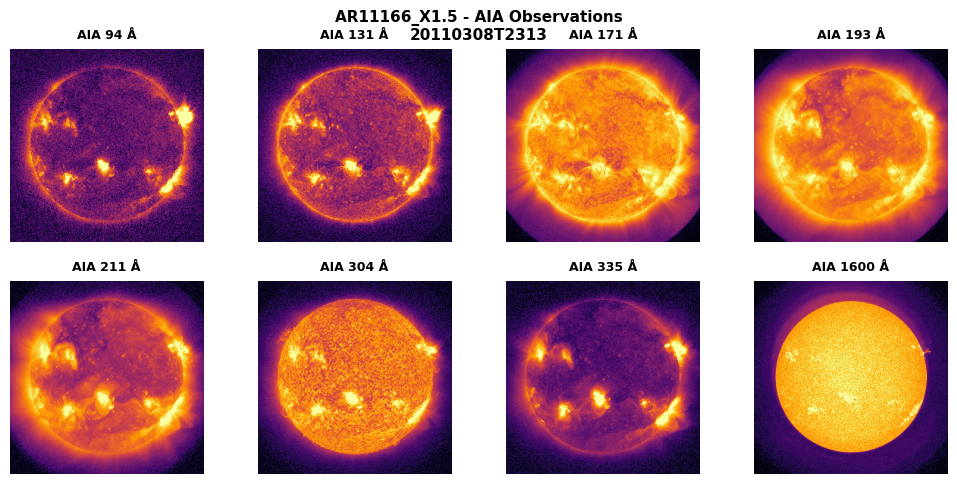


FILE INFORMATION
aia94     : shape=(3, 256, 256), dtype=float32, range=[1.00e-06, 3.64e+00]
aia131    : shape=(3, 256, 256), dtype=float32, range=[1.00e-06, 4.82e+00]
aia171    : shape=(3, 256, 256), dtype=float32, range=[1.00e-06, 7.33e+00]
aia193    : shape=(3, 256, 256), dtype=float32, range=[1.00e-06, 7.75e+00]
aia211    : shape=(3, 256, 256), dtype=float32, range=[1.00e-06, 7.36e+00]
aia304    : shape=(3, 256, 256), dtype=float32, range=[1.73e-01, 5.89e+00]
aia335    : shape=(3, 256, 256), dtype=float32, range=[1.00e-06, 5.37e+00]
aia1600   : shape=(3, 256, 256), dtype=float32, range=[1.00e-06, 6.08e+00]


In [7]:
# %%
# ============================================================
# 🎨 VISUALIZE ONE NEW FLARE - AIA 8 CHANNELS
# ============================================================
# Running from flare_data directory
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# --- Choose a flare from the new 23 ---
FLARE_TO_VISUALIZE = "AR11166_X1.5"  # Change to any flare
TIMESTAMP = None  # Will auto-pick first available NPZ

print("="*70)
print(f"VISUALIZING: {FLARE_TO_VISUALIZE}")
print("="*70)

# ✅ FIXED: Direct path since we're in flare_data
flare_path = os.path.join(FLARE_TO_VISUALIZE, "full_disk", "npz_aia")

print(f"📂 Looking in: {flare_path}")

# Check if path exists
if not os.path.exists(flare_path):
    print(f"\n❌ Path not found: {flare_path}")
    print(f"\n📂 Available flares in current directory:")
    for f in sorted(os.listdir(".")):
        if os.path.isdir(f) and not f.startswith('.'):
            print(f"   {f}")
    raise FileNotFoundError(f"Path not found: {flare_path}")

# Find NPZ files
npz_files = sorted([f for f in os.listdir(flare_path) if f.endswith('.npz')])

if not npz_files:
    raise FileNotFoundError(f"No NPZ files found in {flare_path}")

print(f"✅ Found {len(npz_files)} NPZ files")

# Pick first NPZ if timestamp not specified
if TIMESTAMP is None:
    npz_file = npz_files[0]
else:
    npz_file = f"{TIMESTAMP}.npz"

npz_path = os.path.join(flare_path, npz_file)

print(f"\n📂 Loading: {npz_path}")

# --- Load data ---
data = np.load(npz_path)
print(f"✅ Available channels: {list(data.keys())}")

# --- Smart display function ---
def smart_display(frame):
    """Normalize frame to [0,1] using 1–99 percentile and flip vertically."""
    f = np.nan_to_num(frame)
    lo, hi = np.percentile(f, 1), np.percentile(f, 99)
    f = np.clip(f, lo, hi)
    f = (f - lo) / (hi - lo + 1e-6)
    return np.flipud(f)

def extract_frame(arr):
    """Extract a single 2D frame from array of any shape."""
    if arr.ndim == 2:
        return arr
    elif arr.ndim == 3:
        if arr.shape[0] < arr.shape[2]:
            mid = arr.shape[0] // 2
            return arr[mid, :, :]
        else:
            mid = arr.shape[2] // 2
            return arr[:, :, mid]
    else:
        raise ValueError(f"Unexpected array shape: {arr.shape}")

# --- AIA channels ---
channels = ["aia94", "aia131", "aia171", "aia193", 
           "aia211", "aia304", "aia335", "aia1600"]
titles = ["AIA 94 Å", "AIA 131 Å", "AIA 171 Å", "AIA 193 Å",
         "AIA 211 Å", "AIA 304 Å", "AIA 335 Å", "AIA 1600 Å"]

available = [ch for ch in channels if ch in data]
n = len(available)

print(f"\n📊 Visualizing {n} AIA channels:")

# --- Create figure ---
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(10, 5))
axes = np.array(axes).reshape(-1)

for i, ch in enumerate(available):
    arr = data[ch]
    print(f"   {ch:10s} shape: {arr.shape}")
    
    # Extract 2D frame
    frame_2d = extract_frame(arr)
    frame = smart_display(frame_2d)
    
    ax = axes[i]
    ax.imshow(frame, cmap="inferno", origin="lower")
    ax.set_title(titles[i], fontsize=9, fontweight="bold", pad=8)
    ax.axis("off")
    ax.set_facecolor("black")

# Hide unused subplots
for ax in axes[len(available):]:
    ax.remove()

plt.suptitle(f"{FLARE_TO_VISUALIZE} - AIA Observations\n{npz_file.replace('.npz', '')}",
             fontsize=11, fontweight="bold", y=0.98)
plt.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.05,
                    wspace=0.15, hspace=0.20)

# Save
os.makedirs("figures", exist_ok=True)
plt.savefig(f"figures/check_{FLARE_TO_VISUALIZE}_aia.pdf", bbox_inches="tight", dpi=300)
plt.savefig(f"figures/check_{FLARE_TO_VISUALIZE}_aia.png", bbox_inches="tight", dpi=300)
print(f"\n✅ Saved: figures/check_{FLARE_TO_VISUALIZE}_aia.png")

plt.show()

# --- Print file info ---
print("\n" + "="*70)
print("FILE INFORMATION")
print("="*70)
for ch in available:
    arr = data[ch]
    print(f"{ch:10s}: shape={arr.shape}, dtype={arr.dtype}, "
          f"range=[{arr.min():.2e}, {arr.max():.2e}]")
print("="*70)

In [8]:
# %%
# ============================================================
# 📋 QUICK CHECK - ALL 23 NEW FLARES
# ============================================================
# Running from flare_data directory
# ============================================================

import os
import numpy as np

print("="*70)
print("QUICK CHECK: 23 NEW FLARES")
print("="*70)

# List of 23 new flares
NEW_FLARES = [
    "AR11166_X1.5", "AR11261_M6.0", "AR11261_M9.3b", "AR11283_M5.3",
    "AR11283_X2.1", "AR11283_X1.8", "AR11283_M6.7", "AR11302_M7.4",
    "AR11402_M8.7", "AR11429_X1.3", "AR11429_M8.4", "AR11476_M5.7",
    "AR11515_M5.6", "AR11515_M5.3", "AR11515_M6.1", "AR11877_M9.3",
    "AR11884_M6.3", "AR11884_M5.0", "AR11890_X1.1a", "AR11890_X1.1b",
    "AR11936_M6.4", "AR11944_M7.2", "AR12035_X1.3"
]

print(f"\nChecking {len(NEW_FLARES)} newly downloaded flares:\n")

summary = []

for flare_name in NEW_FLARES:
    # ✅ FIXED: Direct path since we're in flare_data
    flare_path = os.path.join(flare_name, "full_disk", "npz_aia")
    
    if not os.path.isdir(flare_path):
        print(f"❌ {flare_name:20s} → Folder not found")
        summary.append((flare_name, 0, 0, "Missing"))
        continue
    
    # Count NPZ files
    npz_files = [f for f in os.listdir(flare_path) if f.endswith('.npz')]
    
    if not npz_files:
        print(f"⚠️  {flare_name:20s} → No NPZ files")
        summary.append((flare_name, 0, 0, "No NPZ"))
        continue
    
    # Check first NPZ for channel count
    first_npz = os.path.join(flare_path, npz_files[0])
    try:
        data = np.load(first_npz)
        n_channels = len(data.keys())
        
        status = "✅ Complete" if n_channels == 8 else f"⚠️  {n_channels}/8 ch"
        print(f"{status} {flare_name:20s} → {len(npz_files)} NPZ files, {n_channels} channels")
        summary.append((flare_name, len(npz_files), n_channels, "OK"))
        
    except Exception as e:
        print(f"❌ {flare_name:20s} → Error: {e}")
        summary.append((flare_name, len(npz_files), 0, f"Error: {e}"))

# Summary statistics
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

total_flares = len(NEW_FLARES)
ok_flares = sum(1 for _, _, _, s in summary if s == "OK")
total_npz = sum(n for _, n, _, s in summary if s == "OK")

print(f"\nTotal new flares: {total_flares}")
print(f"  ✅ Downloaded successfully: {ok_flares}")
print(f"  ⚠️  Issues: {total_flares - ok_flares}")

if ok_flares > 0:
    print(f"\nTotal NPZ files: {total_npz}")
    print(f"Average per flare: {total_npz/ok_flares:.1f} NPZ files")

# List problematic flares
problems = [(f, s) for f, _, _, s in summary if s != "OK"]
if problems:
    print(f"\n⚠️  Flares with issues:")
    for flare, status in problems:
        print(f"   {flare}: {status}")

print("\n" + "="*70)

QUICK CHECK: 23 NEW FLARES

Checking 23 newly downloaded flares:

✅ Complete AR11166_X1.5         → 6 NPZ files, 8 channels
✅ Complete AR11261_M6.0         → 6 NPZ files, 8 channels
✅ Complete AR11261_M9.3b        → 6 NPZ files, 8 channels
✅ Complete AR11283_M5.3         → 6 NPZ files, 8 channels
✅ Complete AR11283_X2.1         → 6 NPZ files, 8 channels
✅ Complete AR11283_X1.8         → 6 NPZ files, 8 channels
✅ Complete AR11283_M6.7         → 6 NPZ files, 8 channels
✅ Complete AR11302_M7.4         → 6 NPZ files, 8 channels
✅ Complete AR11402_M8.7         → 6 NPZ files, 8 channels
✅ Complete AR11429_X1.3         → 6 NPZ files, 8 channels
✅ Complete AR11429_M8.4         → 6 NPZ files, 8 channels
✅ Complete AR11476_M5.7         → 6 NPZ files, 8 channels
✅ Complete AR11515_M5.6         → 6 NPZ files, 8 channels
✅ Complete AR11515_M5.3         → 6 NPZ files, 8 channels
✅ Complete AR11515_M6.1         → 6 NPZ files, 8 channels
✅ Complete AR11877_M9.3         → 6 NPZ files, 8 channels
✅ Comp